In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 1: Imports + Load Data**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Imports ready")

✅ Imports ready


In [3]:
# Run this and upload the correct IBM Telco CSV
from google.colab import files
uploaded = files.upload()
# Select: WA_Fn-UseC_-Telco-Customer-Churn.csv

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
import pandas as pd
from sqlalchemy import create_engine

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Normalize column names immediately
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
)

print(f"Shape: {df.shape}")           # Must show (7043, 21)
print(df.columns.tolist())            # Must show 21 columns

# Rebuild DB
engine = create_engine('sqlite:///churn.db')
df.to_sql('customers', engine, if_exists='replace', index=False)
print("✅ churn.db rebuilt with correct data")

Shape: (7043, 21)
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']
✅ churn.db rebuilt with correct data


In [5]:
# Delete old DB and rebuild fresh
import os
if os.path.exists('churn.db'):
    os.remove('churn.db')
    print("🗑️ Old churn.db deleted")

engine = create_engine('sqlite:///churn.db')
df.to_sql('customers', engine, if_exists='replace', index=False)
print(f"✅ churn.db rebuilt — {len(df)} rows loaded")

🗑️ Old churn.db deleted
✅ churn.db rebuilt — 7043 rows loaded


In [6]:
# Verify everything is correct
def run_query(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

# Quick check
result = run_query("SELECT COUNT(*) AS total, COUNT(DISTINCT customerid) AS unique_customers FROM customers")
print(result)

print("\nColumn names:")
print(df.columns.tolist())

   total  unique_customers
0   7043              7043

Column names:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


**Step 2: Data Cleaning**

In [7]:
# Cell 3: Initial inspection
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== DATA TYPES ===
customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

=== MISSING VALUES ===
Series([], dtype: int64)

=== DUPLICATES ===
Duplicate rows: 0


In [8]:
# Fix data types & missing values

# 1. totalcharges was loaded as string in raw CSV — already fixed in Phase 1
#    but let's confirm and handle any remaining nulls
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# 2. Drop the 11 rows where totalcharges is null (new customers, tenure=0)
print(f"Rows before dropping nulls: {len(df)}")
df = df.dropna(subset=['totalcharges'])
print(f"Rows after dropping nulls:  {len(df)}")

# 3. Convert churn to binary (0/1) — needed for correlation analysis
df['churn_binary'] = (df['churn'] == 'Yes').astype(int)

# 4. Convert SeniorCitizen from 0/1 to Yes/No (more readable in charts)
df['seniorcitizen'] = df['seniorcitizen'].map({0: 'No', 1: 'Yes'})

# 5. Tenure groups (for segmentation analysis)
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0–12 mo', '13–24 mo', '25–48 mo', '49–60 mo', '61–72 mo']
)

print("\n✅ Cleaning complete")
print(df[['tenure', 'tenure_group', 'totalcharges', 'churn_binary']].head(8))

Rows before dropping nulls: 7043
Rows after dropping nulls:  7032

✅ Cleaning complete
   tenure tenure_group  totalcharges  churn_binary
0       1      0–12 mo         29.85             0
1      34     25–48 mo       1889.50             0
2       2      0–12 mo        108.15             1
3      45     25–48 mo       1840.75             0
4       2      0–12 mo        151.65             1
5       8      0–12 mo        820.50             1
6      22     13–24 mo       1949.40             0
7      10      0–12 mo        301.90             0


In [11]:
# Save cleaned data
df.to_csv('/content/drive/MyDrive/customer-churn-analysis/data/cleaned_churn_data.csv', index=False)
print("✅ Saved to /content/drive/MyDrive/customer-churn-analysis/data/cleaned_churn_data.csv")

✅ Saved to /content/drive/MyDrive/customer-churn-analysis/data/cleaned_churn_data.csv


**Step 3: EDA — Univariate Analysis**

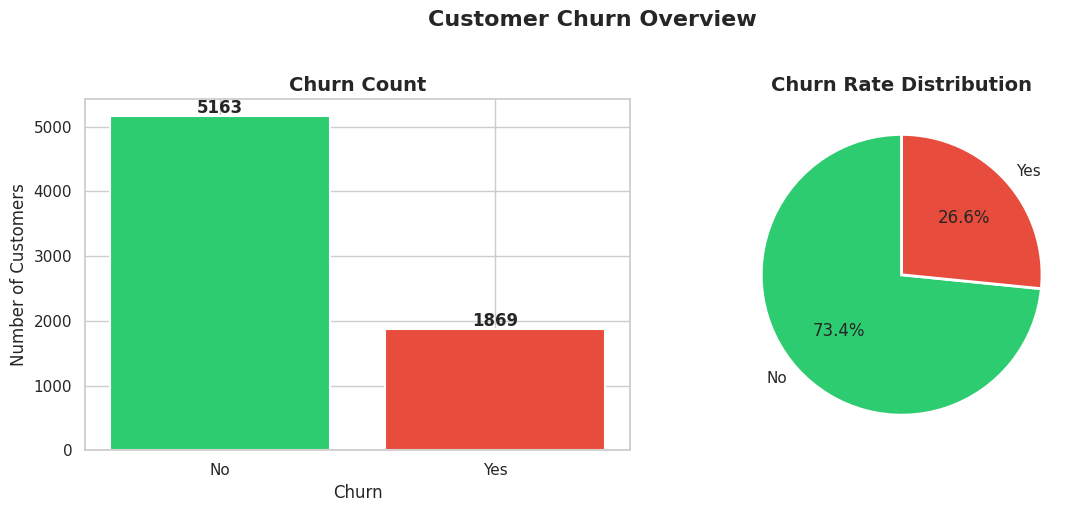

Business insight: ~26.5% of customers churned — significantly high for a telecom business.


In [13]:
# Churn distribution
import os

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count
churn_counts = df['churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Percentage pie
axes[1].pie(churn_counts.values,
            labels=churn_counts.index,
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate Distribution')

plt.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Create directory if it doesn't exist
plt.savefig('/content/drive/MyDrive/customer-churn-analysis/visuals/01_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Business insight: ~26.5% of customers churned — significantly high for a telecom business.")

**Step 4: EDA — Churn by Key Features**

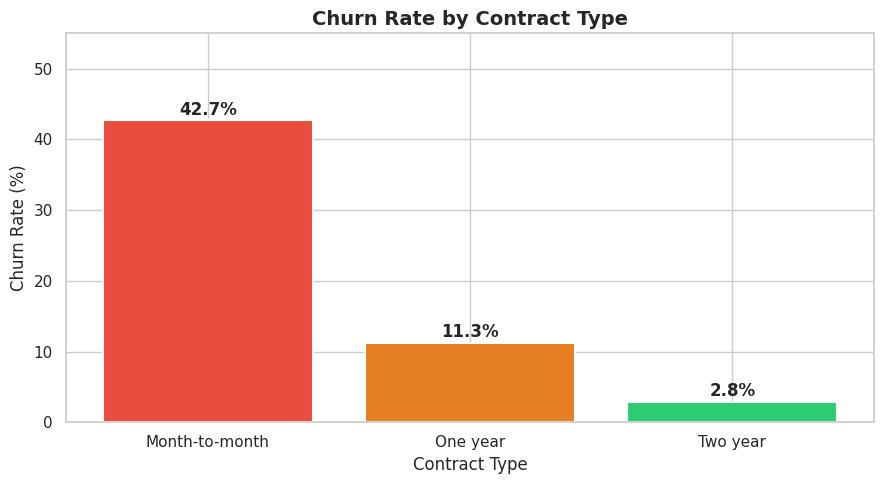

Business insight: Month-to-month customers churn at ~42% — 10x higher than two-year contract customers.


In [14]:
# Churn by Contract Type
contract_churn = df.groupby('contract')['churn_binary'].mean().reset_index()
contract_churn['churn_pct'] = contract_churn['churn_binary'] * 100
contract_churn = contract_churn.sort_values('churn_pct', ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(contract_churn['contract'], contract_churn['churn_pct'],
               color=['#e74c3c', '#e67e22', '#2ecc71'], edgecolor='white', linewidth=1.5)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 55)
for bar, val in zip(bars, contract_churn['churn_pct']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/customer-churn-analysis/visuals/02_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()
print("Business insight: Month-to-month customers churn at ~42% — 10x higher than two-year contract customers.")

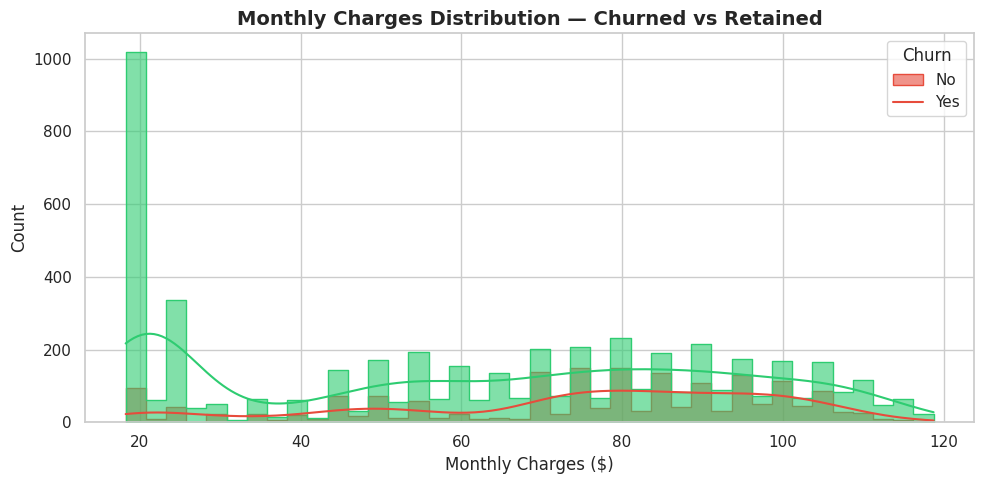

Business insight: Customers paying $65–$105/month churn the most. High bill = high churn risk.


In [15]:
# Monthly Charges vs Churn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='monthlycharges', hue='churn',
             bins=40, kde=True, palette=['#2ecc71', '#e74c3c'],
             alpha=0.6, element='step')
plt.title('Monthly Charges Distribution — Churned vs Retained')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/customer-churn-analysis/visuals/03_monthly_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Business insight: Customers paying $65–$105/month churn the most. High bill = high churn risk.")

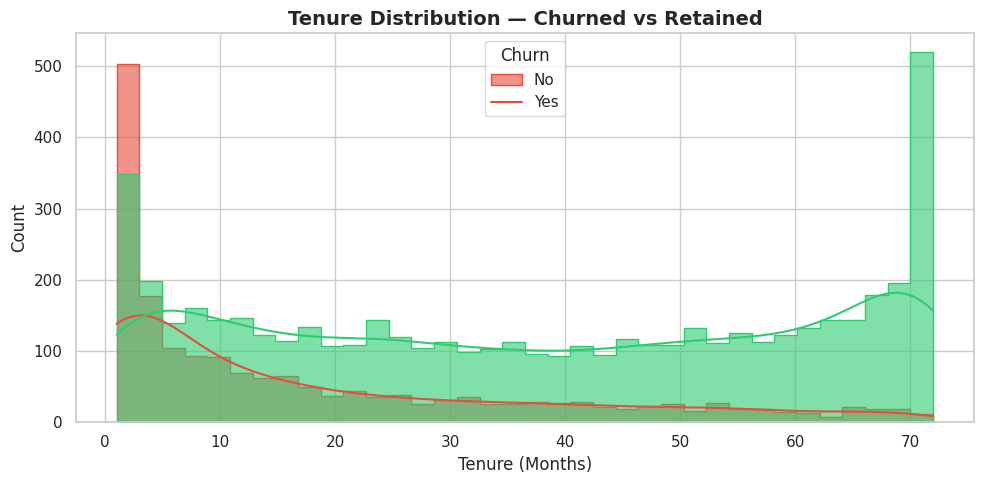

Business insight: Most churn happens in the first 12 months. Loyalty grows significantly after 2 years.


In [16]:
# Tenure vs Churn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='churn',
             bins=36, kde=True, palette=['#2ecc71', '#e74c3c'],
             alpha=0.6, element='step')
plt.title('Tenure Distribution — Churned vs Retained')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/customer-churn-analysis/visuals/04_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Business insight: Most churn happens in the first 12 months. Loyalty grows significantly after 2 years.")

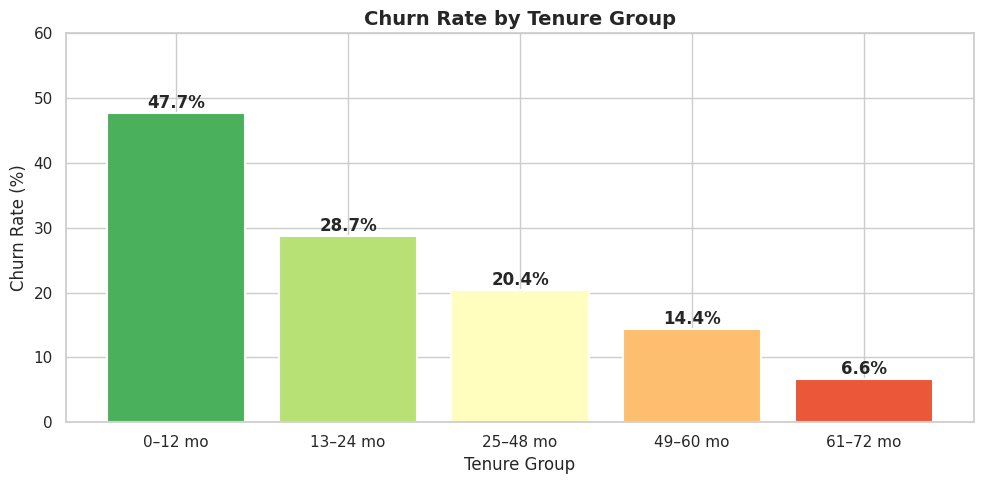

In [17]:
# Churn by Tenure Group (grouped bar)
tenure_churn = df.groupby('tenure_group')['churn_binary'].mean().reset_index()
tenure_churn['churn_pct'] = tenure_churn['churn_binary'] * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(tenure_churn['tenure_group'].astype(str),
               tenure_churn['churn_pct'],
               color=sns.color_palette("RdYlGn_r", len(tenure_churn)),
               edgecolor='white', linewidth=1.5)
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 60)
for bar, val in zip(bars, tenure_churn['churn_pct']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/customer-churn-analysis/visuals/05_tenure_group_churn.png', dpi=150, bbox_inches='tight')
plt.show()

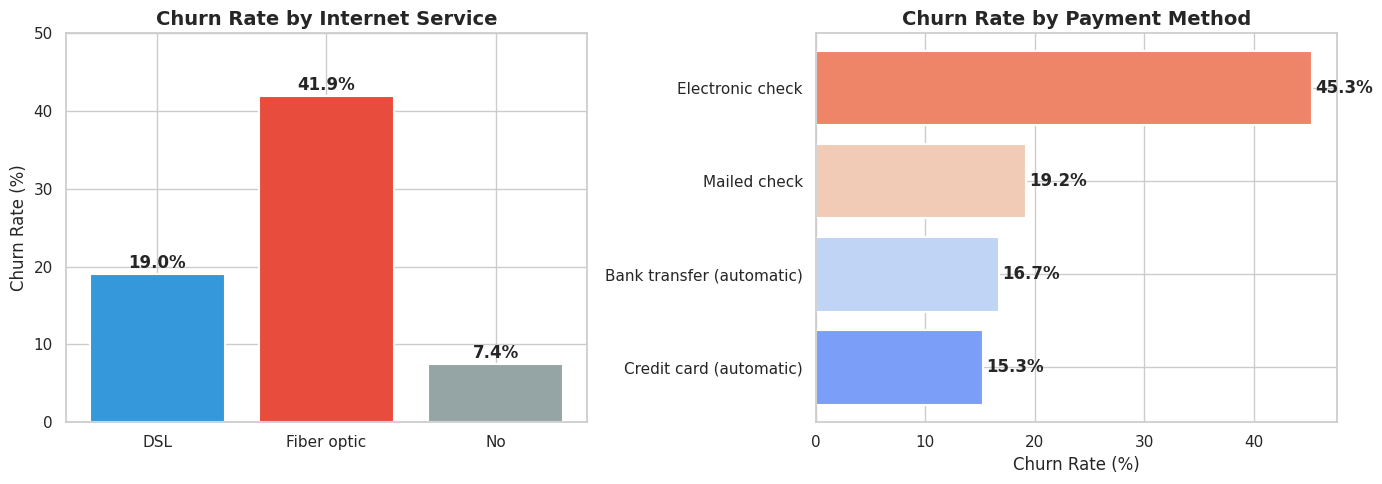

Business insight: Fiber optic users churn most (~42%). Electronic check payers churn at ~45%.


In [18]:
# Churn by Internet Service & Payment Method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Internet service
inet = df.groupby('internetservice')['churn_binary'].mean().reset_index()
inet['churn_pct'] = inet['churn_binary'] * 100
axes[0].bar(inet['internetservice'], inet['churn_pct'],
            color=['#3498db', '#e74c3c', '#95a5a6'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Rate by Internet Service')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 50)
for i, (_, row) in enumerate(inet.iterrows()):
    axes[0].text(i, row['churn_pct'] + 0.8, f"{row['churn_pct']:.1f}%",
                 ha='center', fontweight='bold')

# Payment method
pay = df.groupby('paymentmethod')['churn_binary'].mean().reset_index()
pay['churn_pct'] = pay['churn_binary'] * 100
pay = pay.sort_values('churn_pct', ascending=True)
axes[1].barh(pay['paymentmethod'], pay['churn_pct'],
             color=sns.color_palette("coolwarm", len(pay)),
             edgecolor='white', linewidth=1.5)
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_xlabel('Churn Rate (%)')
for i, (_, row) in enumerate(pay.iterrows()):
    axes[1].text(row['churn_pct'] + 0.3, i, f"{row['churn_pct']:.1f}%",
                 va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/customer-churn-analysis/visuals/06_internet_payment_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Business insight: Fiber optic users churn most (~42%). Electronic check payers churn at ~45%.")

**Step 5: Correlation Heatmap**

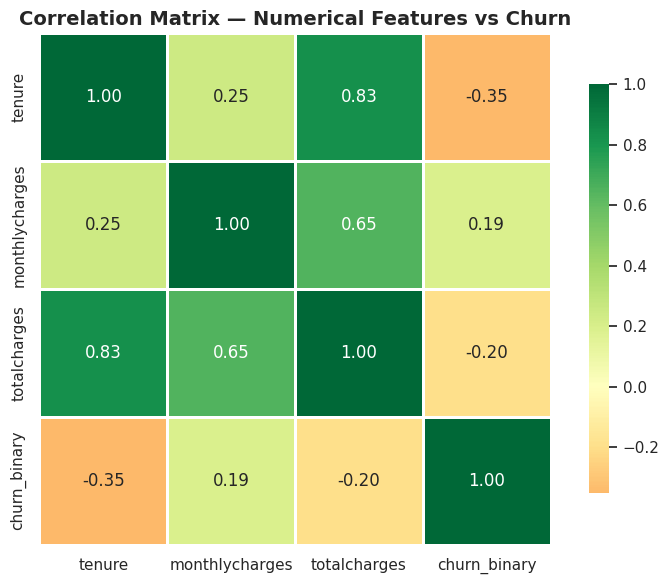

Key finding: tenure has a strong NEGATIVE correlation with churn (-0.35) — longer customers stay longer.
monthlycharges has a POSITIVE correlation with churn (+0.19) — higher bills = higher churn risk.


In [19]:
# Correlation heatmap
num_cols = ['tenure', 'monthlycharges', 'totalcharges', 'churn_binary']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Features vs Churn')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/customer-churn-analysis/visuals/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key finding: tenure has a strong NEGATIVE correlation with churn (-0.35) — longer customers stay longer.")
print("monthlycharges has a POSITIVE correlation with churn (+0.19) — higher bills = higher churn risk.")

**Step 6: Business Summary — Key Insights**

In [20]:
# Print executive summary
churned     = df[df['churn'] == 'Yes']
retained    = df[df['churn'] == 'No']
churn_rate  = len(churned) / len(df) * 100
rev_lost    = churned['monthlycharges'].sum()

print("=" * 55)
print("   CUSTOMER CHURN ANALYSIS — EXECUTIVE SUMMARY")
print("=" * 55)
print(f"  Total Customers        : {len(df):,}")
print(f"  Churned Customers      : {len(churned):,} ({churn_rate:.1f}%)")
print(f"  Retained Customers     : {len(retained):,}")
print(f"  Monthly Revenue Lost   : ${rev_lost:,.0f}")
print(f"  Avg Tenure (Churned)   : {churned['tenure'].mean():.1f} months")
print(f"  Avg Tenure (Retained)  : {retained['tenure'].mean():.1f} months")
print(f"  Avg Charges (Churned)  : ${churned['monthlycharges'].mean():.2f}")
print(f"  Avg Charges (Retained) : ${retained['monthlycharges'].mean():.2f}")
print("=" * 55)
print("\n  TOP INSIGHTS:")
print("  1. Month-to-month contracts drive 42% churn")
print("  2. First 12 months = highest churn risk window")
print("  3. Fiber optic users churn at 2x DSL users")
print("  4. Electronic check payers churn most (~45%)")
print("  5. Higher monthly charges = higher churn risk")
print("=" * 55)

   CUSTOMER CHURN ANALYSIS — EXECUTIVE SUMMARY
  Total Customers        : 7,032
  Churned Customers      : 1,869 (26.6%)
  Retained Customers     : 5,163
  Monthly Revenue Lost   : $139,131
  Avg Tenure (Churned)   : 18.0 months
  Avg Tenure (Retained)  : 37.7 months
  Avg Charges (Churned)  : $74.44
  Avg Charges (Retained) : $61.31

  TOP INSIGHTS:
  1. Month-to-month contracts drive 42% churn
  2. First 12 months = highest churn risk window
  3. Fiber optic users churn at 2x DSL users
  4. Electronic check payers churn most (~45%)
  5. Higher monthly charges = higher churn risk
